In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image

In [ ]:
os.makedirs("outputs", exist_ok=True)
os.makedirs("checkpoints", exist_ok=True)

print("Directories created successfully!")

Directories created successfully!


In [ ]:
# ==============================
# Configuration
# ==============================

BATCH_SIZE = 128

IMAGE_SIZE = 28

NOISE_DIM = 100

EPOCHS = 30

LEARNING_RATE = 0.0002

BETA1 = 0.5
BETA2 = 0.999

SAMPLE_INTERVAL = 1

NUM_WORKERS = 2

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        (0.5,),
        (0.5,)
    )
])

dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Dataset size:", len(dataset))
print("Number of batches:", len(dataloader))

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.91MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 129kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.05MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.14MB/s]

Dataset size: 60000
Number of batches: 469


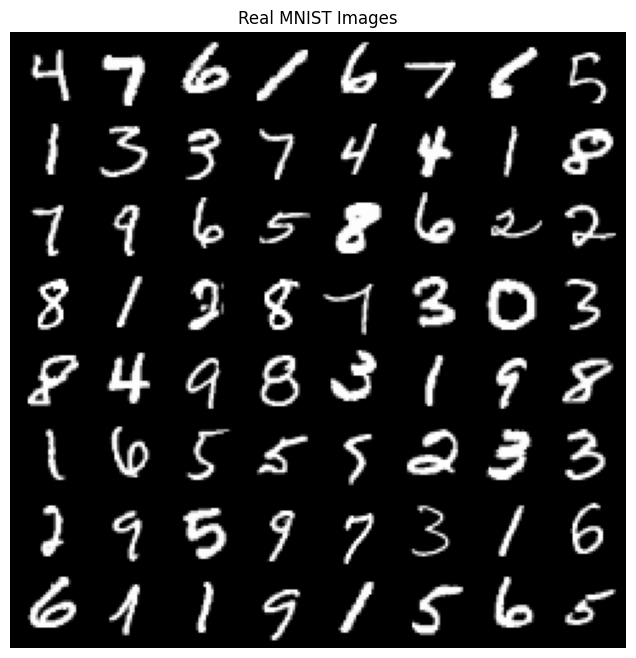

In [ ]:
images, labels = next(iter(dataloader))

grid = make_grid(
    images[:64],
    nrow=8,
    normalize=True
)

plt.figure(figsize=(8, 8))

plt.imshow(
    grid.permute(1, 2, 0).cpu(),
    cmap="gray"
)

plt.axis("off")
plt.title("Real MNIST Images")

plt.show()

In [ ]:
class Generator(nn.Module):

    def __init__(self, noise_dim=100):

        super(Generator, self).__init__()

        self.model = nn.Sequential(

            # 100 → 256
            nn.Linear(noise_dim, 256),
            nn.ReLU(True),

            # 256 → 512
            nn.Linear(256, 512),
            nn.ReLU(True),

            # 512 → 1024
            nn.Linear(512, 1024),
            nn.ReLU(True),

            # 1024 → 784
            nn.Linear(1024, 784),

            # Output range [-1, 1]
            nn.Tanh()
        )

    def forward(self, x):

        x = self.model(x)

        # 784 → 1 × 28 × 28

        x = x.view(
            x.size(0),
            1,
            28,
            28
        )

        return x

In [ ]:
class Discriminator(nn.Module):

    def __init__(self):

        super(Discriminator, self).__init__()

        self.model = nn.Sequential(

            # 784 → 1024
            nn.Linear(784, 1024),
            nn.LeakyReLU(
                0.2,
                inplace=True
            ),

            # 1024 → 512
            nn.Linear(1024, 512),
            nn.LeakyReLU(
                0.2,
                inplace=True
            ),

            # 512 → 1
            nn.Linear(512, 1),

            # Probability
            nn.Sigmoid()
        )

    def forward(self, x):

        # 28 × 28 → 784

        x = x.view(
            x.size(0),
            -1
        )

        return self.model(x)

In [ ]:
generator = Generator(
    noise_dim=NOISE_DIM
).to(device)

discriminator = Discriminator().to(device)

print("Generator:")
print(generator)

print("\nDiscriminator:")
print(discriminator)

Generator:
Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)

Discriminator:
Discriminator(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=1024, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Linear(in_features=512, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [ ]:
def count_parameters(model):

    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


print(
    "Generator parameters:",
    count_parameters(generator)
)

print(
    "Discriminator parameters:",
    count_parameters(discriminator)
)

Generator parameters: 1486352
Discriminator parameters: 1329153


In [ ]:
def count_parameters(model):

    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


print(
    "Generator parameters:",
    count_parameters(generator)
)

print(
    "Discriminator parameters:",
    count_parameters(discriminator)
)

Generator parameters: 1486352
Discriminator parameters: 1329153


In [ ]:
optimizer_G = optim.Adam(
    generator.parameters(),
    lr=LEARNING_RATE,
    betas=(BETA1, BETA2)
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=LEARNING_RATE,
    betas=(BETA1, BETA2)
)

print("Optimizers created successfully!")

Optimizers created successfully!


In [ ]:
fixed_noise = torch.randn(
    64,
    NOISE_DIM,
    device=device
)

print("Fixed noise shape:", fixed_noise.shape)

Fixed noise shape: torch.Size([64, 100])


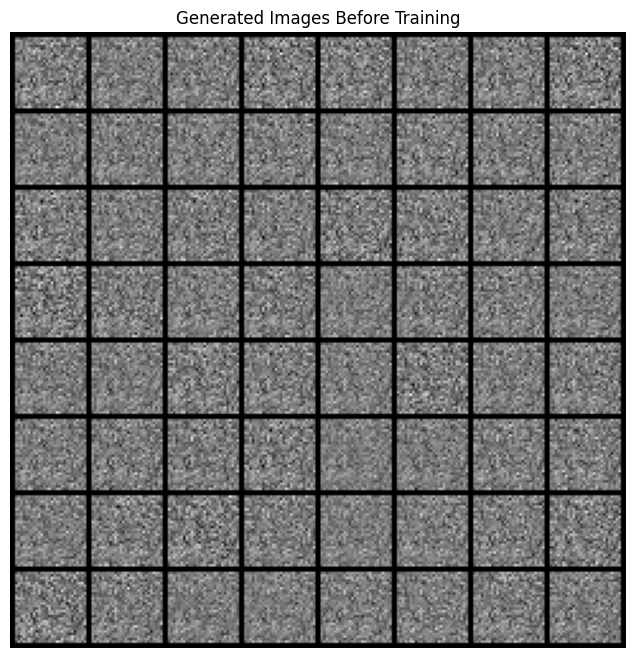

In [ ]:
generator.eval()

with torch.no_grad():

    fake_images = generator(
        fixed_noise
    )

grid = make_grid(
    fake_images,
    nrow=8,
    normalize=True
)

plt.figure(figsize=(8, 8))

plt.imshow(
    grid.permute(1, 2, 0).cpu(),
    cmap="gray"
)

plt.axis("off")
plt.title("Generated Images Before Training")

plt.show()

In [ ]:
# ============================================================
# Training
# ============================================================

criterion = nn.BCELoss()

g_losses = []
d_losses = []

print("=" * 60)
print("Starting GAN Training")
print("=" * 60)

for epoch in range(1, EPOCHS + 1):

    generator.train()
    discriminator.train()

    total_g_loss = 0.0
    total_d_loss = 0.0

    for batch_index, (real_images, _) in enumerate(dataloader):

        # Move real images to GPU
        real_images = real_images.to(
            device,
            non_blocking=True
        )

        batch_size = real_images.size(0)

        # ----------------------------------------------------
        # Labels
        # ----------------------------------------------------

        real_labels = torch.ones(
            batch_size,
            1,
            device=device
        )

        fake_labels = torch.zeros(
            batch_size,
            1,
            device=device
        )

        # ====================================================
        # Train Discriminator
        # ====================================================

        optimizer_D.zero_grad()

        # ----------------------------------------------------
        # Real images
        # ----------------------------------------------------

        real_output = discriminator(
            real_images
        )

        real_loss = criterion(
            real_output,
            real_labels
        )

        # ----------------------------------------------------
        # Generate fake images
        # ----------------------------------------------------

        noise = torch.randn(
            batch_size,
            NOISE_DIM,
            device=device
        )

        fake_images = generator(noise)

        # ----------------------------------------------------
        # Fake images
        # ----------------------------------------------------

        fake_output = discriminator(
            fake_images.detach()
        )

        fake_loss = criterion(
            fake_output,
            fake_labels
        )

        # ----------------------------------------------------
        # Total discriminator loss
        # ----------------------------------------------------

        d_loss = real_loss + fake_loss

        d_loss.backward()

        optimizer_D.step()

        # ====================================================
        # Train Generator
        # ====================================================

        optimizer_G.zero_grad()

        # Generate new noise
        noise = torch.randn(
            batch_size,
            NOISE_DIM,
            device=device
        )

        fake_images = generator(noise)

        fake_output = discriminator(
            fake_images
        )

        # Generator wants fake images
        # to be classified as REAL

        g_loss = criterion(
            fake_output,
            real_labels
        )

        g_loss.backward()

        optimizer_G.step()

        # ----------------------------------------------------
        # Track losses
        # ----------------------------------------------------

        total_d_loss += d_loss.item()
        total_g_loss += g_loss.item()

    # ========================================================
    # Average losses
    # ========================================================

    avg_d_loss = (
        total_d_loss / len(dataloader)
    )

    avg_g_loss = (
        total_g_loss / len(dataloader)
    )

    d_losses.append(avg_d_loss)
    g_losses.append(avg_g_loss)

    # ========================================================
    # Print progress
    # ========================================================

    print(
        f"Epoch [{epoch:02d}/{EPOCHS}] | "
        f"D Loss: {avg_d_loss:.4f} | "
        f"G Loss: {avg_g_loss:.4f}"
    )

    # ========================================================
    # Generate sample images
    # ========================================================

    generator.eval()

    with torch.no_grad():

        generated_images = generator(
            fixed_noise
        )

    save_image(
        generated_images,
        f"outputs/epoch_{epoch:03d}.png",
        nrow=8,
        normalize=True
    )

    # ========================================================
    # Save checkpoints
    # ========================================================

    torch.save(
        generator.state_dict(),
        "checkpoints/generator_latest.pth"
    )

    torch.save(
        discriminator.state_dict(),
        "checkpoints/discriminator_latest.pth"
    )

print()
print("=" * 60)
print("Training completed!")
print("=" * 60)

Starting GAN Training
Epoch [01/30] | D Loss: 0.8166 | G Loss: 1.9427
Epoch [02/30] | D Loss: 0.5645 | G Loss: 3.5682
Epoch [03/30] | D Loss: 0.5244 | G Loss: 3.8310
Epoch [04/30] | D Loss: 0.5017 | G Loss: 4.2258
Epoch [05/30] | D Loss: 0.5610 | G Loss: 4.0536
Epoch [06/30] | D Loss: 0.5767 | G Loss: 4.6357
Epoch [07/30] | D Loss: 0.4657 | G Loss: 3.5897
Epoch [08/30] | D Loss: 0.4320 | G Loss: 3.7204
Epoch [09/30] | D Loss: 0.1174 | G Loss: 18.7024
Epoch [10/30] | D Loss: 0.0000 | G Loss: 48.9656
Epoch [11/30] | D Loss: 0.0000 | G Loss: 48.9656
Epoch [12/30] | D Loss: 0.0000 | G Loss: 48.9717
Epoch [13/30] | D Loss: 0.0000 | G Loss: 48.9313
Epoch [14/30] | D Loss: 0.0000 | G Loss: 48.9236
Epoch [15/30] | D Loss: 0.0000 | G Loss: 48.8689
Epoch [16/30] | D Loss: 0.0000 | G Loss: 48.8592
Epoch [17/30] | D Loss: 0.0000 | G Loss: 48.8173
Epoch [18/30] | D Loss: 0.0000 | G Loss: 48.7572
Epoch [19/30] | D Loss: 0.0000 | G Loss: 48.6573
Epoch [20/30] | D Loss: 0.0000 | G Loss: 48.5195
Epoch 

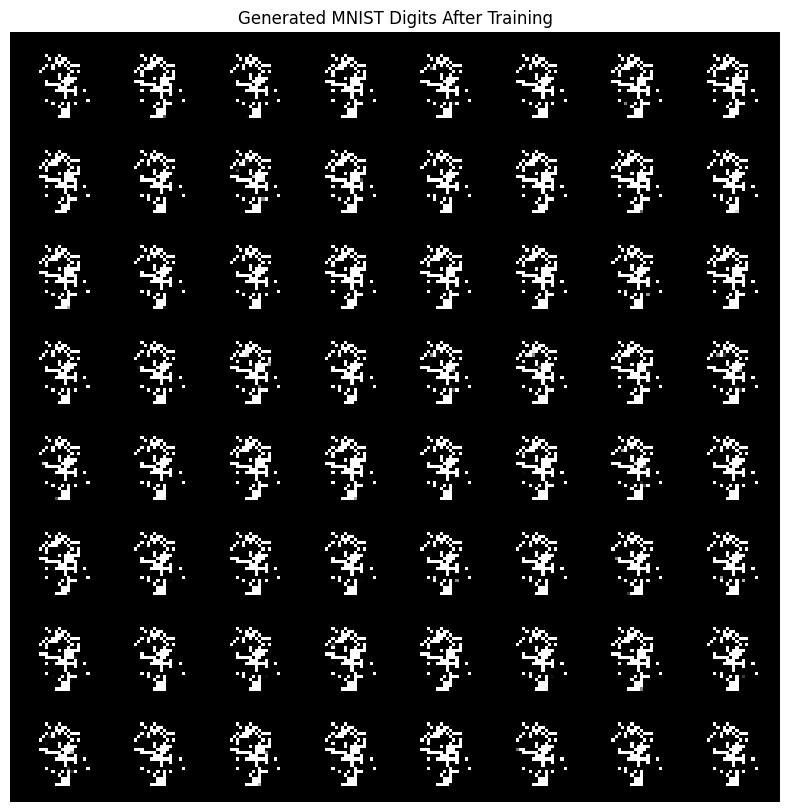

In [ ]:
generator.eval()

with torch.no_grad():

    generated_images = generator(
        fixed_noise
    )

grid = make_grid(
    generated_images,
    nrow=8,
    normalize=True
)

plt.figure(figsize=(10, 10))

plt.imshow(
    grid.permute(1, 2, 0).cpu(),
    cmap="gray"
)

plt.axis("off")

plt.title(
    "Generated MNIST Digits After Training"
)

plt.show()